
IC3392:
  Total valid (finite corrected flux): 73168 (100.00%)
  HII spaxels:                        14884 (20.34%)
  nonHII spaxels:                     33765 (46.15%)
  Unclassified:                       24519 (33.51%)
  (For BPT plotting) valid spaxels (flux>0 + SFR finite): 48620

NGC4064:
  Total valid (finite corrected flux): 155525 (100.00%)
  HII spaxels:                        7067 (4.54%)
  nonHII spaxels:                     98218 (63.15%)
  Unclassified:                       50240 (32.30%)
  (For BPT plotting) valid spaxels (flux>0 + SFR finite): 104388

NGC4192:
  Total valid (finite corrected flux): 489332 (100.00%)
  HII spaxels:                        145944 (29.83%)
  nonHII spaxels:                     276682 (56.54%)
  Unclassified:                       66706 (13.63%)
  (For BPT plotting) valid spaxels (flux>0 + SFR finite): 422619

NGC4293:
  Total valid (finite corrected flux): 250600 (100.00%)
  HII spaxels:                        5715 (2.28%)
  nonHII spaxels

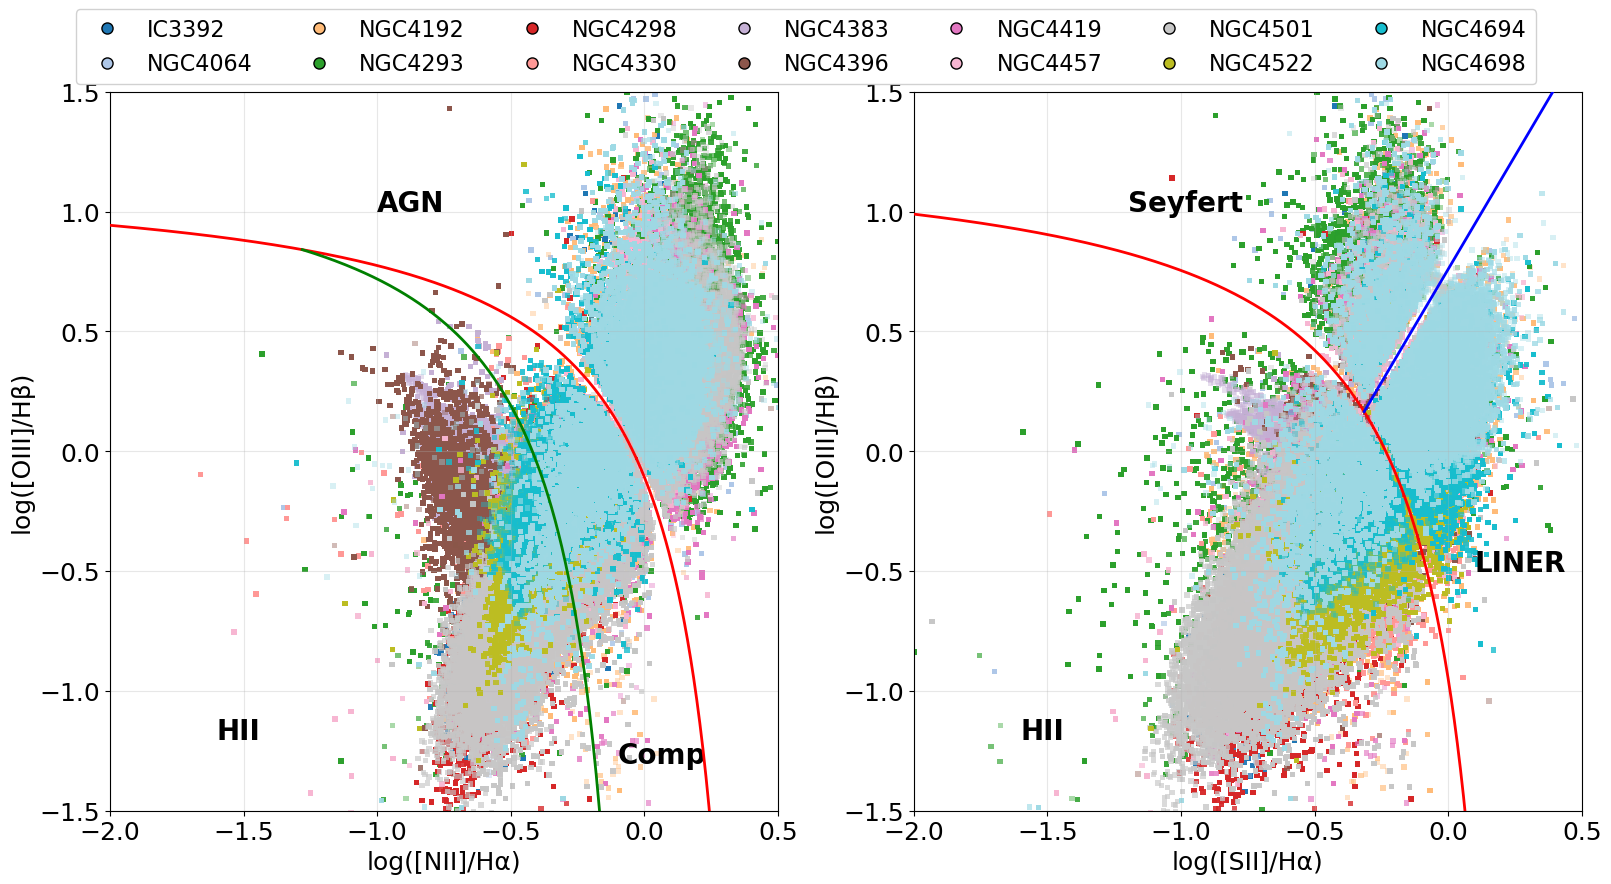

In [1]:
# ------------------------------------------------------------------

# Combined Analysis: NII and SII diagrams - Color-coded by Galaxy

# Collect all spaxels from all galaxies (no HII-only selection)

# Use only dust-corrected emission line fluxes; no O/H needed

# Apply SFR mask: keep spaxels with finite LOGSFR_SURFACE_DENSITY_HII

#                  or LOGSFR_SURFACE_DENSITY_NONHII

# ------------------------------------------------------------------

import numpy as np

import matplotlib.pyplot as plt

from matplotlib.lines import Line2D

from pathlib import Path

from astropy.io import fits


plt_dir = Path('Plot_Paper_1')
plt_dir.mkdir(parents=True, exist_ok=True)


def _pct(part, whole):
    if whole <= 0:
        return np.nan
    return 100.0 * part / whole


# BPT reference line functions (for drawing curves only, if desired)
def kewley01_N2(x):   # max-starburst
    return 0.61/(x-0.47) + 1.19


def kauff03_N2(x):    # empirical SF upper envelope
    return 0.61/(x-0.05) + 1.30


def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30


def kewley06_Sy_LIN(x):   # Seyfert/LINER division
    return 1.89*x + 0.76


# Create x arrays for the theoretical lines (optional overlay)
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)


# Get all galaxies from binning files
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]


# Create galaxy color mapping (consistent for all spaxels)
galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(galaxies)))
galaxy_color_dict = dict(zip(galaxies, galaxy_colors))


# Collect all spaxels from all galaxies (no HII selection), with galaxy indices
all_logN2 = []
all_logO3 = []
all_logS2 = []
all_galaxy_indices = []


print("Collecting all spaxels from all galaxies (using corrected fluxes only, with SFR mask)...")

# Totals across all galaxies (for the summary the user requested)
tot_valid_flux_all = 0
tot_hii_all = 0
tot_nonhii_all = 0
tot_unclassified_all = 0

for gal_idx, gal in enumerate(galaxies):
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')

    if gas_file.exists() and bin_file.exists():
        with fits.open(gas_file) as h:
            # Load corrected emission line fluxes
            HB4861_FLUX_corr = h['HB4861_FLUX_CORR'].data
            HA6562_FLUX_corr = h['HA6562_FLUX_CORR'].data
            OIII5006_FLUX_corr = h['OIII5006_FLUX_CORR'].data
            NII6583_FLUX_corr = h['NII6583_FLUX_CORR'].data
            SII6716_FLUX_corr = h['SII6716_FLUX_CORR'].data
            SII6730_FLUX_corr = h['SII6730_FLUX_CORR'].data

            # Load SFR surface density maps (HII and NONHII)
            logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
            logSigmaSFR_NONHII = h['LOGSFR_SURFACE_DENSITY_NONHII'].data

        # "Total valid spaxel" for reporting: finite corrected fluxes (no SFR requirement)
        valid_flux_mask = (
            np.isfinite(HB4861_FLUX_corr) &
            np.isfinite(HA6562_FLUX_corr) &
            np.isfinite(OIII5006_FLUX_corr) &
            np.isfinite(NII6583_FLUX_corr) &
            np.isfinite(SII6716_FLUX_corr) &
            np.isfinite(SII6730_FLUX_corr)
        )

        # HII / nonHII / unclassified defined via SFR-map finiteness
        hii_mask = valid_flux_mask & np.isfinite(logSigmaSFR_HII)
        nonhii_mask = valid_flux_mask & np.isfinite(logSigmaSFR_NONHII)
        classified_mask = hii_mask | nonhii_mask
        unclassified_mask = valid_flux_mask & (~classified_mask)

        n_valid_flux = int(np.sum(valid_flux_mask))
        n_hii = int(np.sum(hii_mask))
        n_nonhii = int(np.sum(nonhii_mask))
        n_unclassified = int(np.sum(unclassified_mask))

        tot_valid_flux_all += n_valid_flux
        tot_hii_all += n_hii
        tot_nonhii_all += n_nonhii
        tot_unclassified_all += n_unclassified

        print(f"\n{gal}:")
        print(f"  Total valid (finite corrected flux): {n_valid_flux} (100.00%)")
        print(f"  HII spaxels:                        {n_hii} ({_pct(n_hii, n_valid_flux):.2f}%)")
        print(f"  nonHII spaxels:                     {n_nonhii} ({_pct(n_nonhii, n_valid_flux):.2f}%)")
        print(f"  Unclassified:                       {n_unclassified} ({_pct(n_unclassified, n_valid_flux):.2f}%)")

        # For plotting: require fluxes to be finite and positive (so ratios/logs are valid), AND require SFR present (HII or nonHII)
        flux_mask_for_ratios = (
            valid_flux_mask &
            (HB4861_FLUX_corr > 0) & (HA6562_FLUX_corr > 0) &
            (OIII5006_FLUX_corr > 0) & (NII6583_FLUX_corr > 0) &
            (SII6716_FLUX_corr > 0) & (SII6730_FLUX_corr > 0)
        )
        sfr_mask = (np.isfinite(logSigmaSFR_HII) | np.isfinite(logSigmaSFR_NONHII))
        valid_mask = flux_mask_for_ratios & sfr_mask

        n_pixels = int(np.sum(valid_mask))
        print(f"  (For BPT plotting) valid spaxels (flux>0 + SFR finite): {n_pixels}")

        HB_common = HB4861_FLUX_corr[valid_mask]
        HA_common = HA6562_FLUX_corr[valid_mask]
        OIII_common = OIII5006_FLUX_corr[valid_mask]
        NII_common = NII6583_FLUX_corr[valid_mask]
        SII6716_common = SII6716_FLUX_corr[valid_mask]
        SII6730_common = SII6730_FLUX_corr[valid_mask]

        # Calculate line ratios for all valid spaxels
        logN2 = np.log10(NII_common / HA_common)
        logO3 = np.log10(OIII_common / HB_common)
        logS2 = np.log10((SII6716_common + SII6730_common) / HA_common)

        all_logN2.extend(logN2.flatten())
        all_logO3.extend(logO3.flatten())
        all_logS2.extend(logS2.flatten())
        all_galaxy_indices.extend([gal_idx] * len(logN2.flatten()))
    else:
        print(f"  {gal}: Data files not found")


print("\n=== Combined (all galaxies) ===")
print(f"Total valid (finite corrected flux): {tot_valid_flux_all} (100.00%)")
print(f"HII spaxels:                        {tot_hii_all} ({_pct(tot_hii_all, tot_valid_flux_all):.2f}%)")
print(f"nonHII spaxels:                     {tot_nonhii_all} ({_pct(tot_nonhii_all, tot_valid_flux_all):.2f}%)")
print(f"Unclassified:                       {tot_unclassified_all} ({_pct(tot_unclassified_all, tot_valid_flux_all):.2f}%)")


# Convert to numpy arrays
all_logN2 = np.array(all_logN2)
all_logO3 = np.array(all_logO3)
all_logS2 = np.array(all_logS2)
all_galaxy_indices = np.array(all_galaxy_indices)

print(f"\nTotal combined spaxels used in BPT plotting (flux>0 + SFR finite): {len(all_logN2)}")


# Create diagrams for all spaxels (colored by galaxy), no BPT masks
fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)


# NII diagram
ax = axes[0]
for gal_idx, gal in enumerate(galaxies):
    gal_mask = (all_galaxy_indices == gal_idx)
    if np.sum(gal_mask) > 0:
        ax.scatter(all_logN2[gal_mask], all_logO3[gal_mask],
                   color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4,
                   edgecolors='none', rasterized=True)


# Optional: overlay BPT curves as reference only
ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=2, label='Kewley+01', zorder=10)
ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=2, label='Kauffmann+03', zorder=10)

ax.set_xlabel('log([NII]/Hα)', fontsize=18)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_xlim(-2.0, 0.5)
ax.set_ylim(-1.5, 1.5)
ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
ax.text(-0.1, -1.3, 'Comp', fontsize=20, fontweight='bold')
ax.text(-1.0, 1.0, 'AGN', fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.3)


# SII diagram
ax = axes[1]
for gal_idx, gal in enumerate(galaxies):
    gal_mask = (all_galaxy_indices == gal_idx)
    if np.sum(gal_mask) > 0:
        ax.scatter(all_logS2[gal_mask], all_logO3[gal_mask],
                   color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4,
                   edgecolors='none', rasterized=True)

ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=2, label='Kewley+01', zorder=10)
ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=2, label='Kewley+06', zorder=10)

ax.set_xlabel('log([SII]/Hα)', fontsize=18)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_xlim(-2.0, 0.5)
ax.set_ylim(-1.5, 1.5)
# ax.set_title('SII BPT (Common HII spaxels by Galaxy)', fontsize=14)
ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
ax.text(-1.2, 1.0, 'Seyfert', fontsize=20, fontweight='bold')
ax.text(0.1, -0.5, 'LINER', fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.3)


# Build custom legend handles with larger markers
legend_handles = []
legend_labels = []
for gal_idx, gal in enumerate(galaxies):
    legend_handles.append(Line2D([0], [0], marker='o', color='none',
                                 markerfacecolor=galaxy_colors[gal_idx], markersize=8, linestyle='None'))
    legend_labels.append(f'{gal}')


# Put legend above the axes at 1.1 (outside plot)
fig.legend(legend_handles, legend_labels, loc='upper center',
           bbox_to_anchor=(0.5, 1.1),
           ncol=min(len(legend_labels), 7), fontsize=16, framealpha=0.9)


# Save figures
# fig.savefig(plt_dir / 'Combined_BPT_diagrams_by_Galaxy_HII_NONHII.png', dpi=600, bbox_inches='tight', pad_inches=0.05)
# fig.savefig(plt_dir / 'Combined_BPT_diagrams_by_Galaxy_HII_NONHII.pdf', dpi=600, bbox_inches='tight', pad_inches=0.05)

print(f"\nSuccessfully created combined NII/SII diagrams (flux+SFR mask, no BPT masks) colored by galaxy from {len(galaxies)} galaxies")
print(f"Galaxies included: {', '.join(galaxies)}")